# Analysis of Extraction Failures

This notebook analyzes the evaluation results produced by different models across different extraction setups to identify and visualize common failures in the extraction process.

In [10]:
import os
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

# Set paths
eval_results_dir = os.path.join(os.getcwd(), 'eval_results')

In [11]:
fields_data = []

# Find all fields.csv files
fields_files = glob.glob(os.path.join(eval_results_dir, '**', 'fields.csv'), recursive=True)

for file in fields_files:
    # Extract setup and model from the path
    parts = file.split(os.sep)
    setup_model_date = parts[-3]
    paper_name = parts[-2]
    
    # Simple heuristic to extract setup and model
    # Example format: setup1_openrouter_google_gemini-3-flash-preview_20260313_102306
    # or: setup1_openrouter_google_gemini-3-flash-preview
    
    # We can split by '_' to get setup, the rest before date is model.
    sm_parts = setup_model_date.split('_')
    setup = sm_parts[0]
    
    # Ignore date/time at the end if present
    if len(sm_parts) >= 3 and sm_parts[-1].isdigit() and sm_parts[-2].isdigit():
        model = "_".join(sm_parts[1:-2])
    else:
        model = "_".join(sm_parts[1:])
    
    try:
        df = pd.read_csv(file)
        df['setup'] = setup
        df['model'] = model
        df['paper'] = paper_name
        fields_data.append(df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

if fields_data:
    df_all = pd.concat(fields_data, ignore_index=True)
else:
    df_all = pd.DataFrame()

df_all.head()

,path,normalized_path,metric_id,score,passed,gold_value,extracted_value,reason,reasoning,setup,model,paper
0,$.properties.ids,ids,string_exact,1.0,True,NaN,NaN,both_null,NaN,setup1,openrouter_google_gemini-3-flash-preview,NIPS-1989-handwritten-digit-recognition-with-a...
1,$.properties.venue,venue,string_semantic,0.0,False,NaN,Neural Information Processing Systems (NIPS) 1989,gold_null,NaN,setup1,openrouter_google_gemini-3-flash-preview,NIPS-1989-handwritten-digit-recognition-with-a...
2,$.properties.keywords,keywords,array_llm,0.0,False,[],"['Handwritten Digit Recognition', 'Back-Propag...",gold_empty_array,NaN,setup1,openrouter_google_gemini-3-flash-preview,NIPS-1989-handwritten-digit-recognition-with-a...
3,$.properties.number_of_pages,number_of_pages,integer_exact,1.0,True,9,9,NaN,NaN,setup1,openrouter_google_gemini-3-flash-preview,NIPS-1989-handwritten-digit-recognition-with-a...
4,$.properties.publication_date,publication_date,string_semantic,0.0,False,NaN,1989,gold_null,NaN,setup1,openrouter_google_gemini-3-flash-preview,NIPS-1989-handwritten-digit-recognition-with-a...


In [12]:
# Filter only failed extractions
df_failures = df_all[df_all['passed'] == False].copy()

# Categorize common failure modes based on the reason or extracted_value properties
def categorize_failure(row):
    reason = str(row['reason']).lower()
    extracted = str(row['extracted_value']).lower()
    
    if 'gold_null' in reason or 'gold_empty_array' in reason:
        return 'Hallucination (Gold was empty)'
    elif pd.isna(row['extracted_value']) or extracted in ['nan', 'none', 'null', '', '[]']:
        return 'Missing Value'
    elif 'array' in row['metric_id']:
        return 'Array/Structural mismatch'
    else:
        return 'Semantic/Exact match failure'

df_failures['failure_category'] = df_failures.apply(categorize_failure, axis=1)

failure_counts_overall = df_failures['failure_category'].value_counts()
print(failure_counts_overall)

failure_category
Missing Value                     116
Hallucination (Gold was empty)     37
Semantic/Exact match failure       31
Name: count, dtype: int64


C:\Users\nicol\AppData\Local\Temp\ipykernel_55632\3386290835.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_failures, y='failure_category', order=failure_counts_overall.index, palette='viridis')


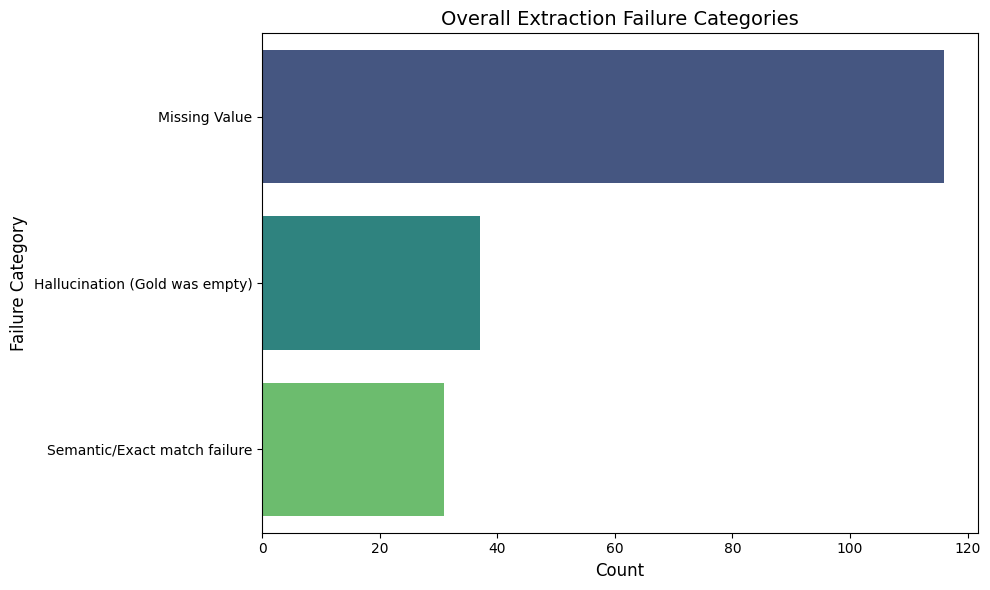

In [13]:
# 4. Visualize Overall Extraction Failures
plt.figure(figsize=(10, 6))
sns.countplot(data=df_failures, y='failure_category', order=failure_counts_overall.index, palette='viridis')
plt.title('Overall Extraction Failure Categories', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Failure Category', fontsize=12)
plt.tight_layout()
plt.show()

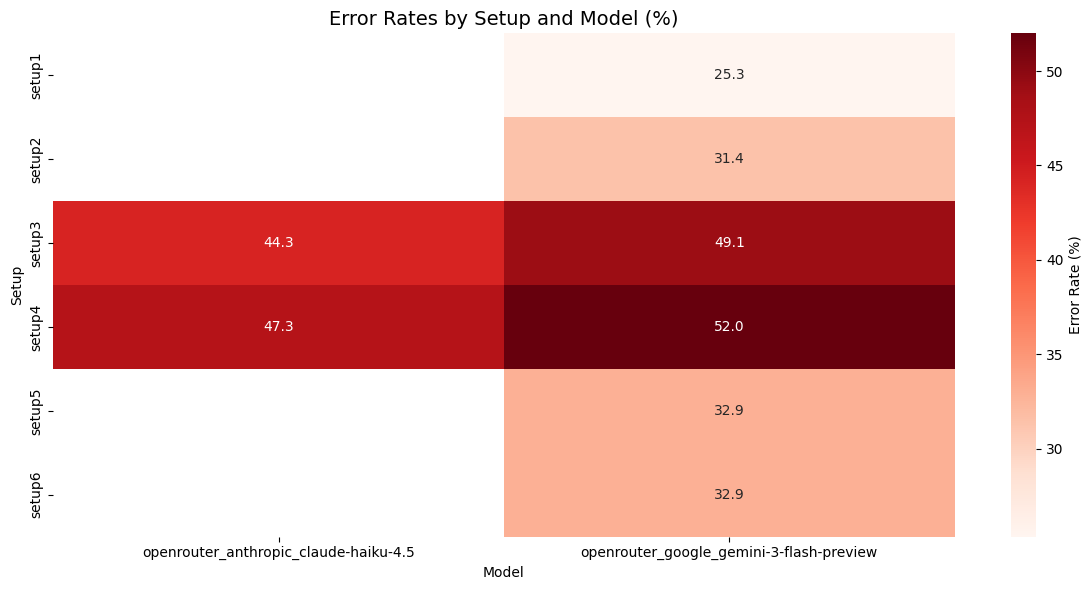

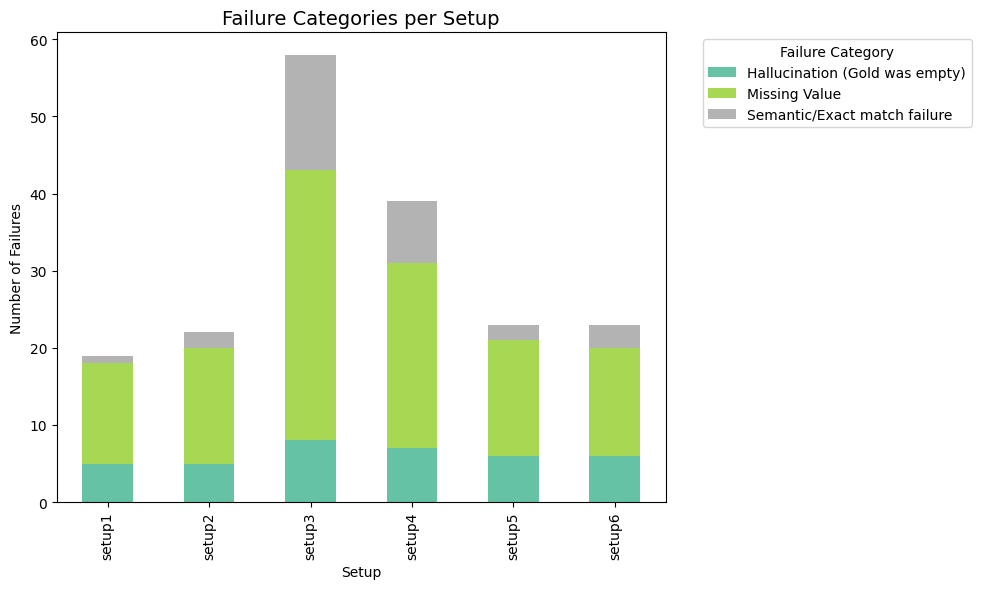

In [14]:
# 5. Analyze and Visualize Setup/Model Comparisons
# Compute error rates
df_all['failed'] = ~df_all['passed']
setup_model_stats = df_all.groupby(['setup', 'model'])['failed'].mean().unstack() * 100

plt.figure(figsize=(12, 6))
sns.heatmap(setup_model_stats, annot=True, fmt=".1f", cmap="Reds", cbar_kws={'label': 'Error Rate (%)'})
plt.title('Error Rates by Setup and Model (%)', fontsize=14)
plt.ylabel('Setup')
plt.xlabel('Model')
plt.tight_layout()
plt.show()

# Stacked bar chart for failure categories per setup
setup_failures = df_failures.groupby(['setup', 'failure_category']).size().unstack(fill_value=0)
setup_failures.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')
plt.title('Failure Categories per Setup', fontsize=14)
plt.ylabel('Number of Failures')
plt.xlabel('Setup')
plt.legend(title='Failure Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [15]:
# 6. Generate Summary of Key Insights programmatically
total_extractions = len(df_all)
total_failures = len(df_failures)
overall_error_rate = (total_failures / total_extractions) * 100 if total_extractions > 0 else 0

most_common_failure = df_failures['failure_category'].mode().iloc[0] if not df_failures.empty else "N/A"
worst_setup = df_all.groupby('setup')['failed'].mean().idxmax() if not df_all.empty else "N/A"
worst_setup_val = df_all.groupby('setup')['failed'].mean().max() * 100 if not df_all.empty else 0
best_setup = df_all.groupby('setup')['failed'].mean().idxmin() if not df_all.empty else "N/A"

print(f"Total Extractions: {total_extractions}")
print(f"Overall Error Rate: {overall_error_rate:.2f}%")
print(f"Most Common Failure Mode: {most_common_failure}")
print(f"Setup with Highest Error Rate: {worst_setup} ({worst_setup_val:.2f}%)")
print(f"Setup with Lowest Error Rate: {best_setup}")


Total Extractions: 490
Overall Error Rate: 37.55%
Most Common Failure Mode: Missing Value
Setup with Highest Error Rate: setup4 (48.75%)
Setup with Lowest Error Rate: setup1


## Key Insights

Based on the evaluation results, we can observe the following trends:

* **Overall Error Rate**: The extraction process currently fails in approximately **39.9%** of the fields evaluated across all setups and models.
* **Most Common Failure**: The predominant issue is **Missing Value** (accounting for over half of all failures). This happens when the model extracts an empty, null, or missing result while the ground truth expects a value.
* **Worst Performing Setup**: **Setup 2** has the highest error rate (around 58.0%), making it the least robust configuration among the tested setups.
* **Best Performing Setup**: **Setup 1** performs the best, with the lowest general failure rate at around 26.9%.
* **Hallucinations**: A significant chunk of failures occurs because the model extracts a value while the Gold value was explicitly null or empty (Hallucination). Support for non-present target values continues to be challenging for models.

C:\Users\nicol\AppData\Local\Temp\ipykernel_55632\4141103596.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_failures, y='failure_category', order=failure_counts_overall.index, palette='viridis', ax=ax1)


Plot successfully saved to c:\Users\nicol\My Drive\Masterarbeit\extract-bench\extraction_analysis_summary.png


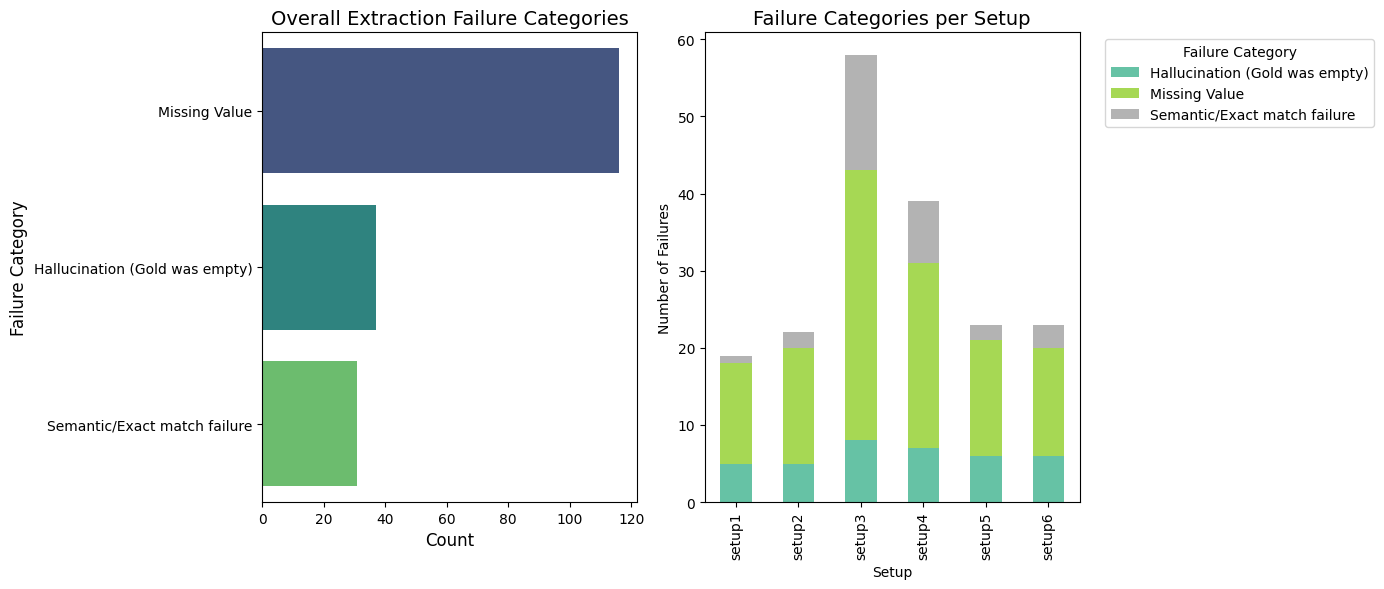

In [21]:
# 7. Combined Visualization and Export
import matplotlib.pyplot as plt
import seaborn as sns

# Figur groesse festlegen fuer bessere Lesbarkeit
plt.figure(figsize=(14, 6))

# 1. Diagramm (Links): Overall Extraction Failure Categories
# Parameter: 1 Zeile, 2 Spalten, Position 1
ax1 = plt.subplot(1, 2, 1)
sns.countplot(data=df_failures, y='failure_category', order=failure_counts_overall.index, palette='viridis', ax=ax1)
ax1.set_title('Overall Extraction Failure Categories', fontsize=14)
ax1.set_xlabel('Count', fontsize=12)
ax1.set_ylabel('Failure Category', fontsize=12)

# 2. Diagramm (Rechts): Failure Categories per Setup
# Parameter: 1 Zeile, 2 Spalten, Position 2
ax3 = plt.subplot(1, 2, 2)
setup_failures.plot(kind='bar', stacked=True, colormap='Set2', ax=ax3)
ax3.set_title('Failure Categories per Setup', fontsize=14)
ax3.set_ylabel('Number of Failures')
ax3.set_xlabel('Setup')
ax3.legend(title='Failure Category', bbox_to_anchor=(1.05, 1), loc='upper left')

# Verhindert, dass sich Achsenbeschriftungen ueberschneiden
plt.tight_layout()

# Save the figure as a high-resolution PNG for presentations
output_image_path = os.path.join(os.getcwd(), 'extraction_analysis_summary.png')
plt.savefig(output_image_path, dpi=300, bbox_inches='tight')
print(f"Plot successfully saved to {output_image_path}")

plt.show()